#** NBA Season Prediction Points per game**

##**Loading a Dataset**

In [26]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/nba-player-stats-2019.csv')
df

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Álex Abrines,SG,25,OKC,31,2,19.0,1.8,5.1,0.357,...,0.923,0.2,1.4,1.5,0.6,0.5,0.2,0.5,1.7,5.3
1,Quincy Acy,PF,28,PHO,10,0,12.3,0.4,1.8,0.222,...,0.700,0.3,2.2,2.5,0.8,0.1,0.4,0.4,2.4,1.7
2,Jaylen Adams,PG,22,ATL,34,1,12.6,1.1,3.2,0.345,...,0.778,0.3,1.4,1.8,1.9,0.4,0.1,0.8,1.3,3.2
3,Steven Adams,C,25,OKC,80,80,33.4,6.0,10.1,0.595,...,0.500,4.9,4.6,9.5,1.6,1.5,1.0,1.7,2.6,13.9
4,Bam Adebayo,C,21,MIA,82,28,23.3,3.4,5.9,0.576,...,0.735,2.0,5.3,7.3,2.2,0.9,0.8,1.5,2.5,8.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,Tyler Zeller,C,29,MEM,4,1,20.5,4.0,7.0,0.571,...,0.778,2.3,2.3,4.5,0.8,0.3,0.8,1.0,4.0,11.5
704,Ante Žižić,C,22,CLE,59,25,18.3,3.1,5.6,0.553,...,0.705,1.8,3.6,5.4,0.9,0.2,0.4,1.0,1.9,7.8
705,Ivica Zubac,C,21,TOT,59,37,17.6,3.6,6.4,0.559,...,0.802,1.9,4.2,6.1,1.1,0.2,0.9,1.2,2.3,8.9
706,Ivica Zubac,C,21,LAL,33,12,15.6,3.4,5.8,0.580,...,0.864,1.6,3.3,4.9,0.8,0.1,0.8,1.0,2.2,8.5


##**Data Preparation**

##**Seperate X and Y**

### **Model Evaluation**

We will evaluate the model's performance using two key metrics:

*   **Mean Squared Error (MSE)**: This measures the average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value. It is a measure of the quality of an estimator—it is always non-negative, and values closer to zero are better.
*   **R-squared (R2)**: This represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 of 1 indicates that the regression predictions perfectly fit the data, while an R2 of 0 indicates that the model explains none of the variability of the response data around its mean.


In [33]:
import pandas as pd

print('LR MSE(Train):', lr_train_mse)
print('LR R2(Train):', lr_train_r2)
print('LR MSE(Test):', lr_test_mse)
print('LR R2(Test):', lr_test_r2)

lr_results = pd.DataFrame([['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]],
                         columns=['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2'])
display(lr_results)

LR MSE(Train): 0.912562096814922
LR R2(Train): 0.9744840237225113
LR MSE(Test): 0.9336970927088302
LR R2(Test): 0.9645144327887548


,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,0.912562,0.974484,0.933697,0.964514


### **Model Interpretation: Feature Coefficients**

The coefficients in a linear regression model indicate the strength and direction of the relationship between each independent variable (feature) and the dependent variable (target). A positive coefficient means that as the feature value increases, the target variable tends to increase, assuming all other features are held constant. Conversely, a negative coefficient suggests that an increase in the feature leads to a decrease in the target variable.


In [34]:
import pandas as pd

feature_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)
display(feature_coefficients)

,Feature,Coefficient
2,FG%,4.482339
1,FGA,1.386391
4,Age,0.026918
0,MP,-0.017524
3,AST,-0.050223
5,3PA,-0.153718


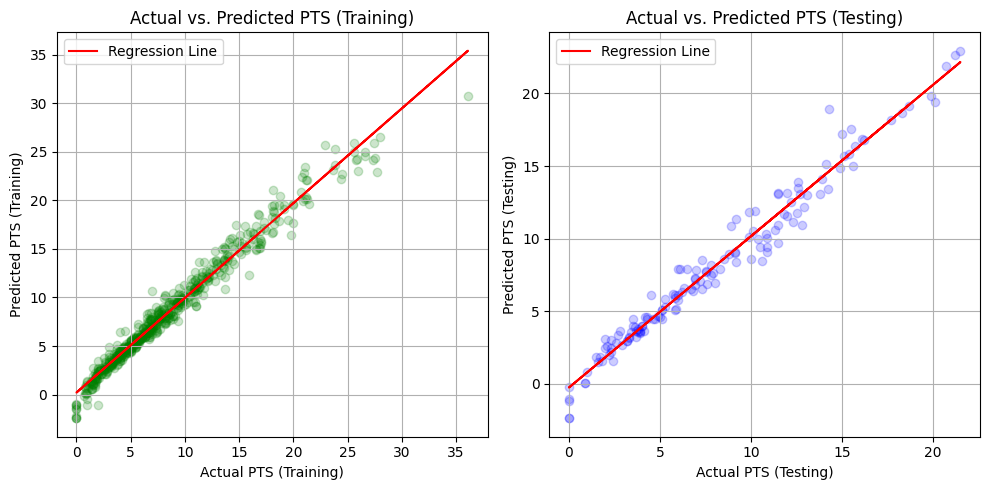

In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# Scatter plot for Training Data
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_lr_train_pred, color='green', alpha=0.2)
# Fit a line for training data
z_train = np.polyfit(y_train, y_lr_train_pred, 1)
plt.plot(y_train, z_train[0]*y_train + z_train[1], color='red', label='Regression Line')
plt.xlabel('Actual PTS (Training)')
plt.ylabel('Predicted PTS (Training)')
plt.title('Actual vs. Predicted PTS (Training)')
plt.grid(True)
plt.legend()

# Scatter plot for Test Data
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_lr_test_pred, color='blue', alpha=0.2)
# Fit a line for test data
z_test = np.polyfit(y_test, y_lr_test_pred, 1)
plt.plot(y_test, z_test[0]*y_test + z_test[1], color='red', label='Regression Line')
plt.xlabel('Actual PTS (Testing)')
plt.ylabel('Predicted PTS (Testing)')
plt.title('Actual vs. Predicted PTS (Testing)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### **Residual Plots**

Residual plots are an essential diagnostic tool in regression analysis. A residual is the difference between an observed value and the value predicted by the regression model ($y_{actual} - y_{predicted}$). Plotting these residuals against the predicted values can reveal patterns that indicate issues with the regression model's assumptions.



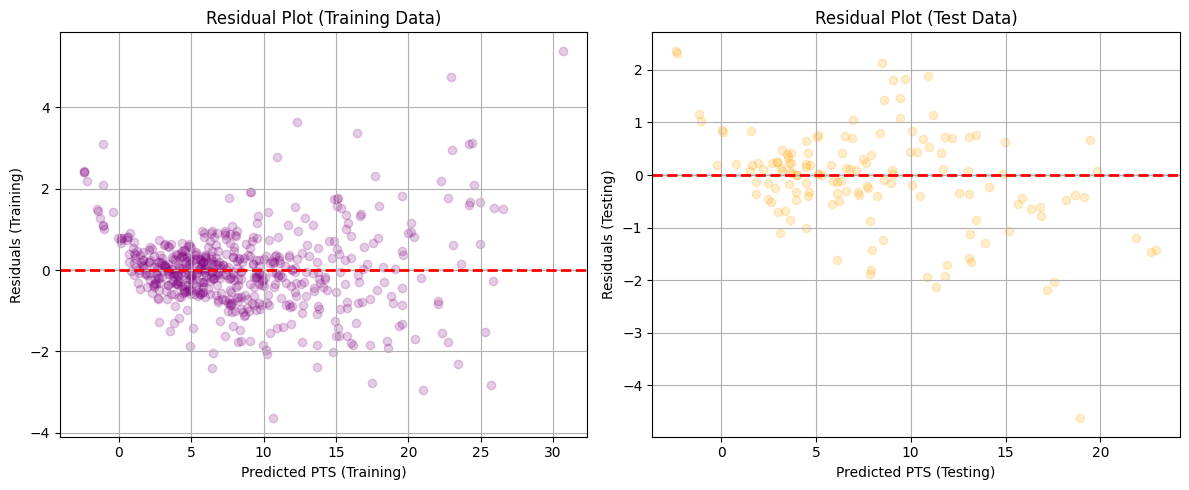

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Residuals for Training Data
plt.subplot(1, 2, 1)
residuals_train = y_train - y_lr_train_pred
plt.scatter(y_lr_train_pred, residuals_train, color='purple', alpha=0.2)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted PTS (Training)')
plt.ylabel('Residuals (Training)')
plt.title('Residual Plot (Training Data)')
plt.grid(True)

# Residuals for Test Data
plt.subplot(1, 2, 2)
residuals_test = y_test - y_lr_test_pred
plt.scatter(y_lr_test_pred, residuals_test, color='orange', alpha=0.2)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted PTS (Testing)')
plt.ylabel('Residuals (Testing)')
plt.title('Residual Plot (Test Data)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
y = df['PTS']
y

,PTS
0,5.3
1,1.7
2,3.2
3,13.9
4,8.9
...,...
703,11.5
704,7.8
705,8.9
706,8.5


In [28]:
X = df[["MP","FGA", "FG%","AST","Age","3PA"]]
X

,MP,FGA,FG%,AST,Age,3PA
0,19.0,5.1,0.357,0.6,25,4.1
1,12.3,1.8,0.222,0.8,28,1.5
2,12.6,3.2,0.345,1.9,22,2.2
3,33.4,10.1,0.595,1.6,25,0.0
4,23.3,5.9,0.576,2.2,21,0.2
...,...,...,...,...,...,...
703,20.5,7.0,0.571,0.8,29,0.0
704,18.3,5.6,0.553,0.9,22,0.0
705,17.6,6.4,0.559,1.1,21,0.0
706,15.6,5.8,0.580,0.8,21,0.0


##**Data Splitting**

In [29]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,MP,FGA,FG%,AST,Age,3PA
522,29.5,13.4,0.453,1.6,23,5.2
24,34.0,10.7,0.399,3.7,33,6.3
480,7.3,2.5,0.400,1.0,23,0.8
314,20.3,4.8,0.459,0.8,22,1.1
239,26.7,10.8,0.504,2.6,32,2.7
...,...,...,...,...,...,...
71,29.9,8.6,0.383,2.0,28,3.5
106,12.9,2.4,0.375,2.3,37,1.2
270,15.8,5.1,0.380,1.8,35,2.9
435,6.5,2.0,0.250,0.0,22,0.5


In [ ]:
X_test

,MP,FGA,FG%,AST,Age,3PA
120,21.2,6.9,0.445,3.1,24,2.0
247,31.7,13.8,0.409,1.9,30,8.8
324,6.5,2.5,0.533,0.8,24,1.0
204,4.9,1.1,0.577,0.3,21,0.0
603,7.1,3.2,0.444,0.7,19,1.5
...,...,...,...,...,...,...
41,27.7,10.7,0.402,2.9,28,4.6
108,21.0,5.5,0.390,2.8,27,3.2
582,17.7,5.3,0.400,0.8,30,3.2
56,27.4,6.1,0.407,3.8,30,3.6


#**Model Building**

##**Linear Regression**

##**Training the Model**

In [30]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

##**Applying the model to make predictions**

In [31]:
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)

In [ ]:
y_lr_train_pred

array([16.86277531, 12.79323702,  2.60906413,  5.7714272 , 14.11215579,
        3.43995534, 12.13452005,  4.35299031,  8.17656868,  3.61445151,
        8.44363877,  6.3902622 ,  4.90143685, 11.71963887,  4.17280914,
        2.15123189,  5.52684557, -1.0932061 ,  5.73964905,  1.43828779,
       14.39286115, 20.90009589, 15.64947042,  2.7812172 , 23.08503448,
        7.42587969, 11.98595726, 18.82526792,  9.3644779 ,  2.13297005,
       11.99124145,  7.60558263, 13.78411632,  2.96441591, 20.37601681,
       11.69894808,  5.32551749,  7.10920919,  5.94043219,  5.11185575,
        8.49294114, 12.27325545,  3.0088071 ,  2.28129098,  5.34969493,
       10.62268156,  5.68718259,  8.25023802,  6.70105917,  4.07944472,
        6.81977171, 17.53634181,  4.77604036,  2.54562726,  6.16213854,
        4.61615853, 11.77886499, 22.06578083,  9.4657943 ,  4.01097382,
        8.54207023,  3.73817675,  0.70739393, 16.1528382 ,  2.71107472,
        6.32725078, 16.60154969,  8.92383341,  5.47748777,  6.96

In [ ]:
y_lr_test_pred

array([ 8.40430098, 16.80152971,  3.22545275,  1.60784201,  3.58005864,
        4.45853388, 14.97036511,  3.64853245,  3.96750203, 13.06708504,
       18.67888723,  5.08887468,  7.70716343, 13.43186353, 13.45694228,
       18.18447451,  1.56152832,  8.46936973,  4.62760358, 13.15686959,
        7.74268656,  7.22311859, 16.3497623 , 10.07135762, 15.16554426,
        9.08851105,  7.87042046,  4.57415198,  5.13116353, 11.69368928,
        3.64423812,  3.22067353,  6.19637927,  5.29821253, 11.14886454,
        3.49477455,  2.19392476,  2.84215484,  6.79377064,  7.91131566,
       19.43849491, 10.83889615,  1.83030921,  4.45577054,  8.57107844,
        9.07402742,  5.91192913,  2.9574662 ,  5.07797501, -2.36625341,
        4.59800201, 14.11902665,  6.11912124,  9.43681392,  3.67776019,
        3.00327925,  7.28335901,  1.52434989,  3.550984  , 15.84269359,
        6.56767401,  6.37770485,  3.75976708, 19.82060826,  2.45114749,
       16.88485305,  7.93421466, 12.19708558, -2.32867639,  6.32

##**Evaulate Model Performence**

In [32]:
from sklearn.metrics import mean_squared_error, r2_score
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred )
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred )
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [ ]:
print('LR MSE(Train):', lr_train_mse)
print('LR R2(Train):', lr_train_r2)
print('LR MSE(Test):', lr_test_mse)
print('LR R2(Test):', lr_test_r2)



LR MSE(Train): 0.912562096814922
LR R2(Train): 0.9744840237225113
LR MSE(Test): 0.9336970927088302
LR R2(Test): 0.9645144327887548


In [ ]:
lr_train_mse

0.912562096814922

In [ ]:
lr_train_r2

0.9744840237225113

In [ ]:
lr_test_mse

0.9336970927088302

In [ ]:
lr_test_r2

0.9645144327887548

In [ ]:
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns =['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

In [ ]:
lr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,0.912562,0.974484,0.933697,0.964514


#**Interpert the Model**

In [ ]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
2,FG%,4.482339
1,FGA,1.386391
4,Age,0.026918
0,MP,-0.017524
3,AST,-0.050223
5,3PA,-0.153718


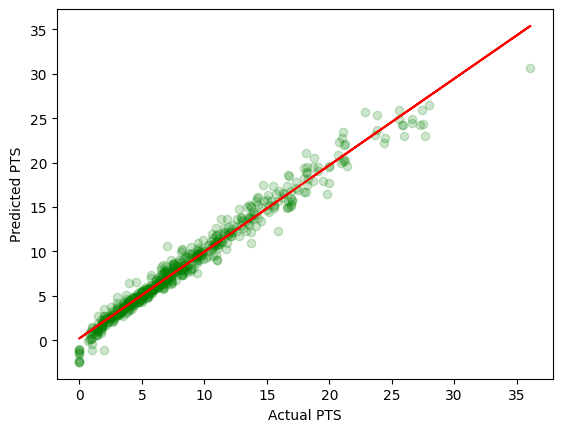

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot
plt.scatter(y_train, y_lr_train_pred, color='green', alpha=0.2)

# Fit a line
z = np.polyfit(y_train, y_lr_train_pred, 1)
plt.plot(y_train, z[0]*y_train + z[1], color='red')

# Labels
plt.xlabel('Actual PTS')
plt.ylabel('Predicted PTS')

plt.show()
